In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
from runner import ejecutar_experimento

Descrivere Arbitro Universale per la Funzione Obiettivo

### **Experimento 1: Greedy Algorithm**

El **Algoritmo Greedy** se implementa en esta práctica como punto de referencia para efectuar la comparativa de resultados con las heuristicas de búsqueda posteriores.

Se basa en la heurística del "vecino más cercano". Partiendo de la estación central (Estación 0), el camión realiza el intercambio de bicicletas para acercar la estación al 50% de su capacidad.

Posteriormente, calcula la distancia Manhattan hacia todas las estaciones pendientes y viaja siempre a la más cercana.

Este proceso iterativo continúa hasta que se han visitado todas le estaciones filtradas y el camión regresa a la Estación 0.

#### **Características**

- **Naturaleza Determinista**: el algoritmo siempre generará la misma ruta para el mismo problema.
- **Ejecución**: se ejecuta *una sola vez* por cada Caso y no es necesario iterar sobre las 5 semillas aleatorias.
- **Evaluación**: realiza 1 sola llamada a la función objetivo.

In [2]:
from algorithms import greedy_algorithm

# Ejecutar Greedy Algorithm
res_greedy = ejecutar_experimento(
    nombre_algoritmo='Greedy Algorithm',
    funcion_algoritmo=greedy_algorithm,
    is_deterministic=True
)


 EXPERIMENTACIÓN: GREEDY ALGORITHM


| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) | Semilla | Mejor FObj |
-----------------------------------------------------------------------------------------------------------
| Caso 1 |      1.5485 |   23.68 |  15.2903 |      1.0 |         1 |       0.0001 |     N/A | ratio      |
| Caso 2 |      1.6087 |   23.77 |  14.7736 |      1.0 |         1 |       0.0001 |     N/A | ratio      |
| Caso 3 |      2.4834 |   23.24 |   9.3560 |      1.0 |         1 |       0.0001 |     N/A | ratio      |
-----------------------------------------------------------------------------------------------------------


#### **Análisis de Resultados: Greedy Algorithm**

La tabla superior muestra el desempeño del algoritmo Greedy:

- **Eficiencia Espacial (`Kms`)**: en los tres casos, la distancia recorrida es estremadamente baja y constante ($23.2 - 23.7 kms$). De hecho, el *Caso 3* presenta la menor distancia de todas.

- **El Límite del Greedy**: a pesar de tener los mejores kilómetros, el *Caso 3* sufre una penalización masiva en su Función Objetivo, saltando de $\approx 1.5$ a a $2.4834$. En efecto, su *Entropia* se desploma a $9.3560$. El *Caso 3* es un escenario extremo donde casi la mitad de las estaciones están completamente vacías. Como el camión tiene una capacidad limitada ($L=20$) y empieza con pocas bicis (7), es físicamente imposible equilibrar la red en una sola pasada.

- **Insensibilidad a la Función Objetivo (`Mejor FObj`):** En la tabla se observa que la función ganadora es siempre `ratio`. Esto no significa que el Ratio sea matemáticamente superior aquí, sino que es un artefacto de la naturaleza del algoritmo. El Greedy toma sus decisiones de movimiento basándose *únicamente en la distancia mínima*, ignorando por completo la Función Objetivo durante la construcción de la ruta. En consecuencia, sin importar qué fórmula (Ratio, Suma, Exponencial) se utiliza, la ruta física generada será idéntica. Al pasar por el "Árbitro Universal", todas las funciones obtienen exactamente el mismo puntaje y se produce un empate técnico cuádruple. El sistema muestra `ratio` simplemente porque es la *primera función evaluada en la lista*, ganando el desempate por defecto.

---


### **Experimento 2: Búsqueda Aleatoria**

El **Algoritmo de Búsqueda Aleatoria** se implementa en esta práctica como la primera aproximación heurística estocástica. Este método no utiliza ninguna lógica espacial ni de proximidad para construir la ruta.

Se basa en la exploración pura del espacio de búsqueda. En cada paso, el algoritmo genera el recorrido del camión de forma completamente aleatoria.

Posteriormente, evalúa esta ruta generada al azar y la compara con la mejor solución que ha encontrado hasta el momento, actualizándola si resulta ser superior según la Función Objetivo.

#### **Características**

- **Naturaleza Estocástica**: el algoritmo depende de la generación de números pseudoaleatorios, por lo que explorará rutas completamente diferentes dependiendo de la *semilla* inicial.

- **Ejecución**: la búsqueda completa se ejecuta 5 veces por cada Caso, utilizando 5 semillas distintas predefinidas. Por cada una de estas semillas, el algoritmo realiza un ciclo de *100 iteraciones*.

- **Evaluación**: realiza exactamente 100 llamadas a la función objetivo en cada ejecución, devolviendo la mejor de todas ella al finalizar.


 EXPERIMENTACIÓN: BÚSQUEDA ALEATORIA


| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) | Semilla | Mejor FObj |
-----------------------------------------------------------------------------------------------------------
| Caso 1 |      1.8035 |   27.71 |  15.3671 |    100.0 |       100 |       0.0019 |     555 | ratio      |
| Caso 2 |      1.8765 |   29.04 |  15.4740 |    100.0 |       100 |       0.0016 |     123 | ratio      |
| Caso 3 |      2.7246 |   34.54 |  12.6770 |    100.0 |       100 |       0.0017 |     555 | ratio      |
-----------------------------------------------------------------------------------------------------------


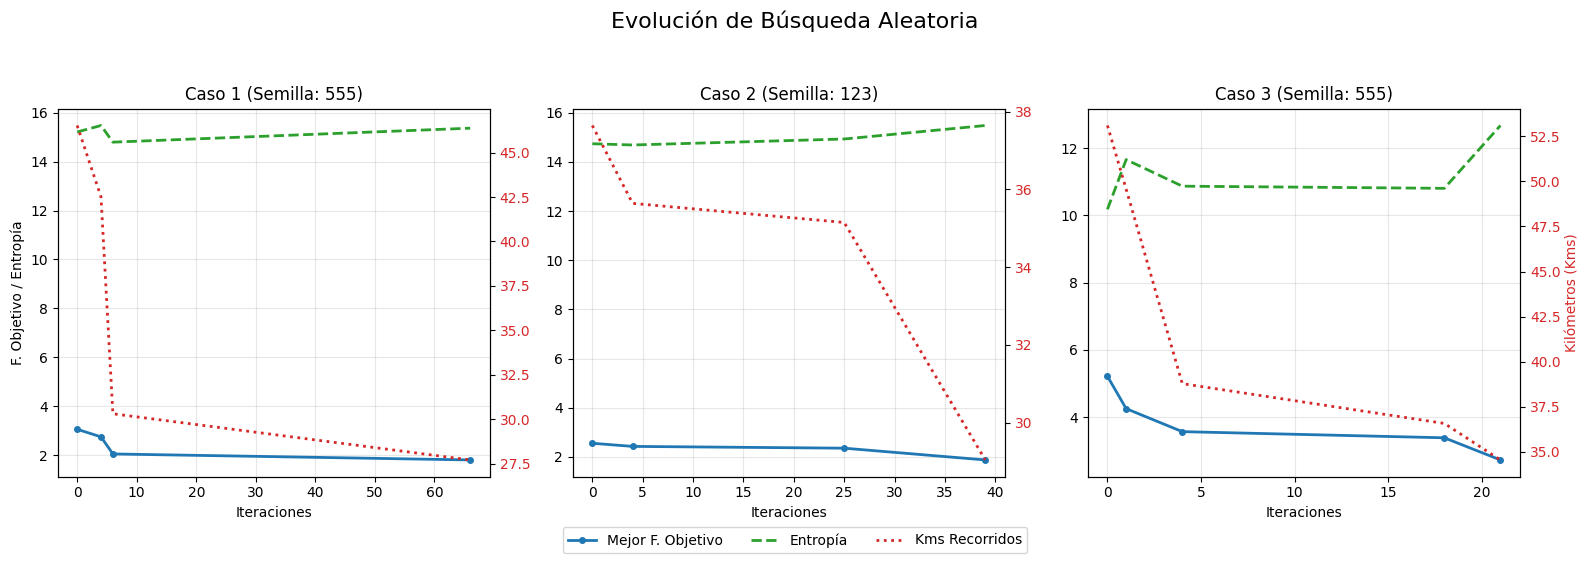

In [3]:
from algorithms import busqueda_aleatoria

# Ejecutar Búsqueda Aleatoria
res_aleatoria = ejecutar_experimento(
    nombre_algoritmo='Búsqueda Aleatoria',
    funcion_algoritmo=busqueda_aleatoria,
    is_deterministic=False,
    max_iter=100
)

### **Análisis de Resultados: Búsqueda Aleatoria**

Al analizar la tabla de resultados y las gráficas de convergencia, se extraen las siguientes conclusiones:

- **El coste de la aleatoriedad (`Kms`)**: la Búsqueda Aleatoria es geográficamente ineficiente. Al generar permutaciones al azar sin ninguna heurística de proximidad, el camión da "saltos" caóticos por la ciudad. Esto se refleja en los kilómetros: dispara las distancias hasta los $27.7 - 34.5 Kms$. En un problema de enrutamiento 100 iteraciones puramente aleatorias son insuficientes para encontrar un camino óptimo por casualidad. Esto hace que la Función Objetivo sea peor que la del Greedy.

- **La Mejora de la Entropía**: A pesar de ser peor en distancia, la Búsqueda Aleatoria ha logrado elevar la entropía del *Caso 3* hasta $12.67$ (y también mejora ligeramente los *Casos 1 y 2*). Sacrificar eficiencia en la ruta (hacer más kilómetros) permite visitar las estaciones en un orden estratégico que distribuye mucho mejor las bicicletas. El camión ha encontrado, por puro azar, una secuencia de visitas que le permite recoger y dejar inventario de forma más inteligente.

- **Análisis Visual de Convergencia (Gráficas)**: las tres gráficas muestran el comportamiento *escalonado* de un algoritmo de exploración estocástica ciega:
    - En las primeras iteraciones (iteraciones 0 a 5), la línea azul ($F.Obj$) y la línea roja (Kilómetros) *caen* en picado. Esto ocurre porque la primera ruta aleatoria generada suele ser disastrosa, y cualquier permutación subsiguiente tiene altas probabilidades de mejorarla dramáticamente.
    - A partir de la iteración 10 o 20, la curva se aplana. Como la Búsqueda Aleatoria no tiene memoria ni explora el vecindario de forma inteligente, encontrar una ruta aleatoria que bata a la mejor actual se vuelve estadísticamente muy improbable.

- **La Función Objetivo Ganadora** es el `ratio`. En la Búsqueda Aleatoria la Función Objetivo actúa como filtro (decide qué ruta aleatoria se queda), por lo tanto el "Árbitro Universal" está filtrando las rutas utilizando exactamente la misma regla métrica con la que se juzga.

---

### **Experimento 3: Búsqueda Local - Mejor Vecino**

El algoritmo de **Búsqueda Local en su variante "Mejor Vecino"** es un método heurístico de intensificación que busca mejorar progresivamente una solución explorando de forma sistemática y exhaustiva su entorno local.

Partiendo de una solución inicial generada de forma aleatoria, el algoritmo evalúa *todas* las permutaciones posibles generadas al aplicar un operador de movimiento. En este caso, el movimiento consiste en intercambiar las posiciones de dos estaciones dentro de la ruta. Como restricción habrá que el primero de la ruta (la Estación 0) permanece inamovible, por lo que los intercambios se realizan únicamente desde la posición 2 hasta la $n$.

#### **Características**

- **Naturaleza Intensificadora**: realiza una exploración determinista exhaustiva del entorno inmediato de una solución estocástica inicial, buscando el descenso más pronunciado en la función de coste.
- **Condiciones de Parada**: el algoritmo posee un doble criterio de detención:
    1. Se detiene de forma natural si alcanza un *óptimo local*;
    2. Como medida de seguridad técnica para evitar tiempos de ejecución exesivos en vecindarios inmensos, se detiene forzosamente si alcanza un límite máximo de *3000 evaluaciones* de la función de coste.
- **Ejecución**: dado que arranca desde una posición inicial estocástica, la búsqueda completa se ejecuta 5 veces por cada Caso, utilizando las 5 semillas distintas predefinidas.


 EXPERIMENTACIÓN: BÚSQUEDA MEJOR VECINO


| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) | Semilla | Mejor FObj |
-----------------------------------------------------------------------------------------------------------
| Caso 1 |      1.5215 |   23.31 |  15.3203 |    262.2 |       221 |       0.0037 |     987 | ratio      |
| Caso 2 |      1.5449 |   24.56 |  15.8971 |    320.0 |       441 |       0.0043 |     987 | ratio      |
| Caso 3 |      2.1814 |   25.65 |  11.7575 |    482.8 |       595 |       0.0066 |     987 | ratio      |
-----------------------------------------------------------------------------------------------------------


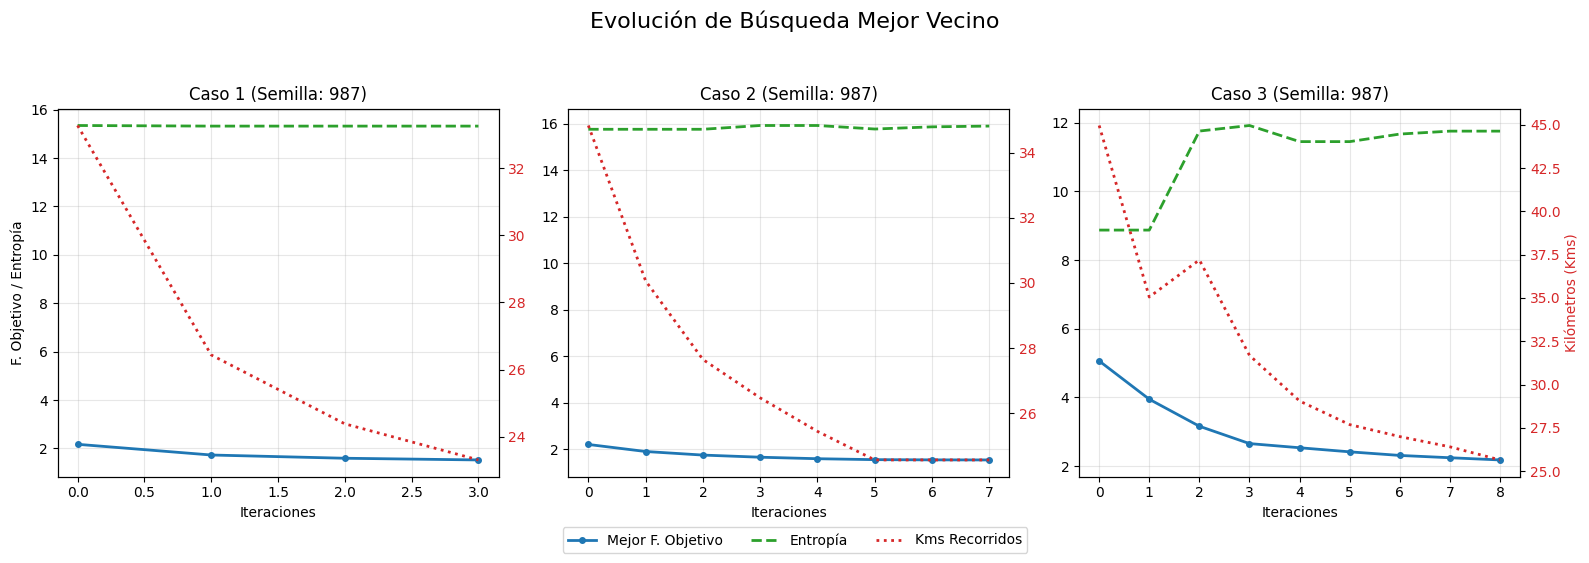

In [4]:
from algorithms import busqueda_local_mejor_vecino

# Ejecutar Búsqueda Mejor Vecino
res_mejor_vecino = ejecutar_experimento(
    nombre_algoritmo='Búsqueda Mejor Vecino',
    funcion_algoritmo=busqueda_local_mejor_vecino,
    is_deterministic=False,
    max_evals=3000
)

### **Análisis de Resultados: Búsqueda Local - Mejor Vecino**

Al comparar esta tabla y las gráficas con los algoritmos anteriores, destacan varios fenómenos clave:

- **Mejora frente al Baseline**: se logra batir la Función Objetivo del algoritmo Greedy en *los tres casos*.
    - En el *Caso 1 y 2*, se alcanzan entropías casi perfectas ($\approx 15.3$ y $15.8$) manteniendo los kilómetros en valores extremadamente bajos ($\approx 23.3$ y $24.5$ Kms).
    - En el *Caso 3* se observa la mayor mejoría: la $F.Obj$ cae de $2.48$ (Greedy) a **$2.18$**. El algoritmo evalúa como preferible realizar un recorrido ligermamente más largo ($25.65$ Kms) para posibilitar intercambios mucho más estratégicos, elevando la Entropía hasta **$11.75$**. El incremento en la distancia se justifica si el equilibrio de la red mejora de manera sustancial.

- **Análisis Visual de Convergencia (Gráficas)**: las gráficas muestran un comportamiento de descenso de gradiente muy pronunciado. En lugar de iterar de forma prolongada, la solución inicial se actualiza en escasas ocasiones (3, 7 y 8 iteraciones respectivamente). En cada uno de esos puntos, la métrica de kilómetros (linea punteada roja) experimento un descenso abrupto. Tras esos pocos pasos, el algoritmo se estanca y la tendencia se vuelve plana. Este patrón indica que se ha alcanzado un *óptimo local*: una topología de ruta donde ningún intercambio de dos estaciones consigue reducir la Función Objetivo, desencadenando la parada natural del algoritmo.

- **Consumo de Evaluaciones (`Ev. Media` y `Ev. Mejor`)**: a diferencia de la Búsqueda Aleatoria, el consumo de evaluaciones es dinámico. El algoritmo finaliza utilizando entre *220 y 600 evaluaciones* en las ejecuciones más óptimas, que evidencia dos factores:
    1. Se trata de un algoritmo computacionalmente muy eficiente, con una velocidad de convergencia alta.
    2. Existe un amplio margen operativo frente al límite de seguridad de *3000 evaluaciones* establecido en las especificaciones, lo que garantiza que la ejecución siempre concluye por el hallazgo de un óptimo local antes de agotar el tiempo computacional.

- **Impacto de la Solución Inicial (`Semilla 987`)**: destaca que esta semilla resulta ser el punto de partida que produce los mejores resultados en los tres casos. Puesto que la Búsqueda Local es un proceso determinista una vez inicializado, su rendimiento está estrictamente condicionado por la calidad de la solución aleatoria de partida. En este experimento, la semilla `987` generó configuraciones iniciales ubicadas en cuencas de atracción sumamente favorables para la optimización.

---

### **Experimento 4: Búsqueda Local - Primer Mejor**

El algoritmo de **Búsqueda Local en su variante "Primer Mejor"** surge como una alternativa computacionalmente más ágil frente a la estrategia del "Mejor Vecino".
En lugar de evaluar exhaustivamente el vecindario completo para determinar el movimiento óptimo absoluto, esta técnica interrumpe la exploración del entorno de forma anticipada al encontrar soluciones que mejoren el estado actual.

Al igual que en el experimento anterior, se parte de una solución inicial estocástica y se define un entorno basado en el intercambio de dos posiciones (omitiendo la Estación 0). Sin embargo, la lógica de exploración incorpora dos diferencias metodológicas fundamentales establecidas en las especificaciones del problema:

1. **Reordenación Aleatoria del Entorno**: antes de comenzar a evaluar a los vecinos, se genera una lista con todas las combinaciones posibles de intercambio y se somete a una reordenación aleatoria (*shuffle*). Esto garantiza que el vecindario no se explore siempre en el mismo orden secuencial, introduciendo un componente estocástico en la dirección de la búsqueda.
2. **Condición de Salida Anticipada**: a medida que se evalúan los vecinos en este orden aleatorio, el algoritmo contabiliza aquellos que logran mejorar la Función Objetivo actual. El bucle de exploración se interrumpe inmediatamente cuando se han encontrado *al menos 3 soluciones mejores*. 
3. **Decisión de Movimiento**: tras la interrupción (o tras explorar todo el entorno si no se logran encontrar 3 mejoras), el algoritmo efectúa el movimiento hacia la mejor solución de las encontradas y reinicia el proceso. 

#### **Características**

- **Naturaleza Acelerada y Estocástica**: al no requerir la evaluación de la totalidad del vecindario en cada paso (salvo cuando se está cerca de un óptimo local), se reduce drásticamente el consumo de evaluaciones. Además, la trayectoria de optimización depende fuertemente de la semilla aleatoria debido al *shuffle* del entorno.
- **Condiciones de Parada**: mantiene el límite de seguridad de **3000 evaluaciones** de la función de coste, o se detiene de forma natural al alcanzar un óptimo local (cero vecinos que mejoren la métrica tras explorar el entorno reordenado completo).
- **Ejecución**: se ejecuta 5 veces por cada Caso de prueba, empleando las 5 semillas predefinidas para garantizar la reproducibilidad de la solución inicial y de la reordenación del entorno.


 EXPERIMENTACIÓN: BÚSQUEDA PRIMER MEJOR


| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) | Semilla | Mejor FObj |
-----------------------------------------------------------------------------------------------------------
| Caso 1 |      1.5215 |   23.31 |  15.3203 |    260.6 |       174 |       0.0037 |     987 | ratio      |
| Caso 2 |      1.5762 |   24.67 |  15.6509 |    292.9 |       331 |       0.0049 |     555 | ratio_cuad |
| Caso 3 |      2.2012 |   25.80 |  11.7194 |    347.0 |       300 |       0.0051 |     987 | ratio_cuad |
-----------------------------------------------------------------------------------------------------------


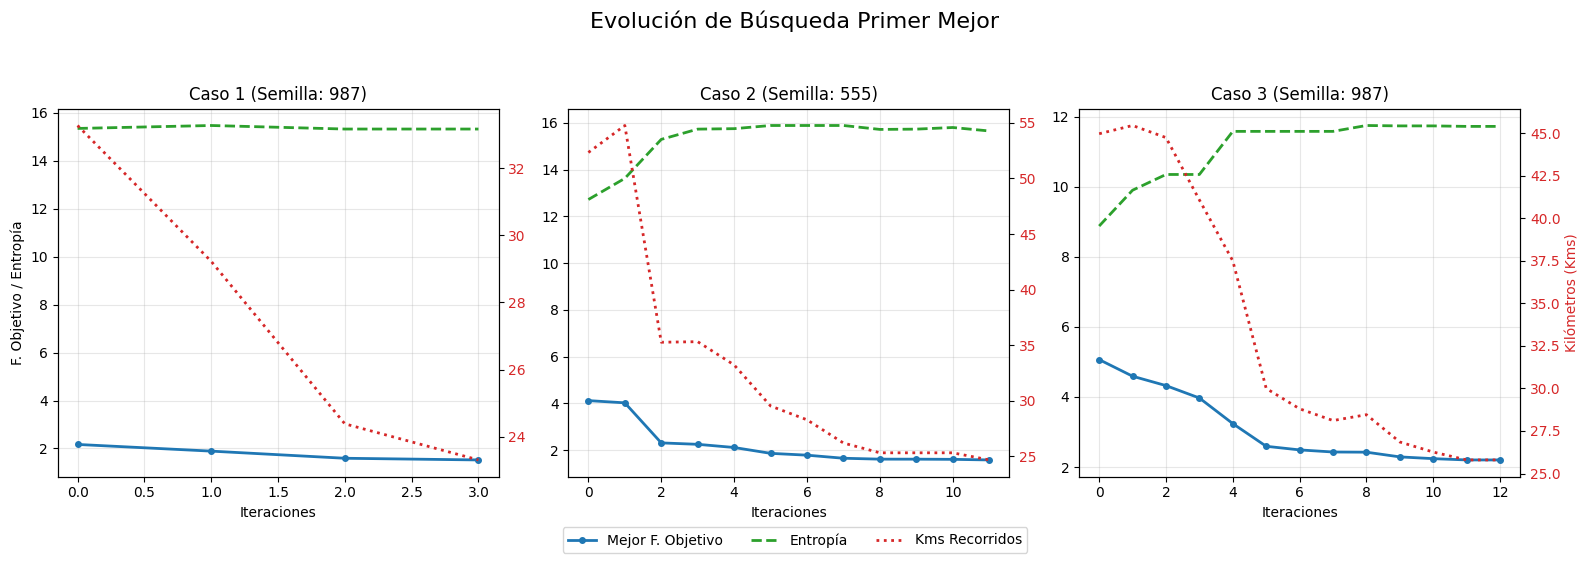

In [5]:
from algorithms import busqueda_local_primer_mejor

# Ejecutar Búsqueda Primer Mejor
res_primer_mejor = ejecutar_experimento(
    nombre_algoritmo='Búsqueda Primer Mejor',
    funcion_algoritmo=busqueda_local_primer_mejor,
    is_deterministic=False,
    max_evals=3000
)

### **Análisis de Resultados: Búsqueda Local (Primer Mejor)**

A partir de los datos tabulados y las curvas de convergencia generadas con la implementación de la Búsqueda Local (Primer Mejor), se extraen las siguientes conclusiones:

- **Competitividad y Calidad de la Solución**: el algoritmo demuestra una notable capacidad de optimización, obteniendo resultados extremadamente competitivos que, en términos generales, empatan o rozan el rendimiento de la exhaustiva variante "Mejor Vecino". 
  - En el *Caso 1*, el "Primer Mejor" alcanza un valor de **$1.5215$** en el Árbitro Universal, igualando exactamente el resultado del Mejor Vecino, al encontrar una ruta de **$23.31$ Kms** con una entropía de **$15.32$**.
  - En los *Casos 2 y 3*, los resultados ($1.5762$ y $2.2012$ respectivamente) muestran una desviación mínima respecto al enfoque de búsqueda completa. En todos los escenarios evaluados, esta variante supera de manera contundente la línea base establecida por el algoritmo Greedy.

- **Eficiencia Computacional (`Ev. Media` y `Ev. Mejor`)**: se constata el principal beneficio teórico de esta heurística: la contención de la carga computacional en problemas de gran dimensionalidad. El número de evaluaciones medias se sitúa en un rango moderado de **260 a 347 evaluaciones**. La condición de salida anticipada cumple su propósito algorítmico, evitando evaluar la totalidad del vecindario en cada salto y acelerando la toma de decisiones, especialmente lejos del óptimo local.

- **Convergencia Visual y Pasos de Optimización**: al analizar las gráficas, se observa que el descenso de la Función Objetivo es más gradual y requiere una mayor cantidad de actualizaciones de la solución base. Mientras el "Mejor Vecino" convergía en escasos saltos (3 a 8), el "Primer Mejor" requiere un mayor número de iteraciones (hasta **11 o 12 cambios de solución** en los Casos 2 y 3). Esto confirma el comportamiento esperado de la heurística: al no seleccionar siempre el descenso más pronunciado disponible en el entorno, la trayectoria de optimización requiere recorrer "más pasos" topológicos para alcanzar el valle del óptimo local.

- **El Impacto de la Función Objetivo (`Mejor FObj`)**: Un hallazgo crítico de esta experimentación es la validación empírica de la modularidad de la función de coste. En los *Casos 2 y 3*, la métrica que guio a la mejor ruta física no fue el `ratio` simple, sino el **`ratio_cuadrático`** ($Kms / Entropía^2$). 
Al emplear una reordenación aleatoria del entorno (*shuffle*), la elección de la función matemática utilizada para ponderar a los vecinos cobra una importancia vital. El ratio cuadrático, que penaliza de forma mucho más agresiva la baja entropía, altera la topología percibida del espacio de búsqueda, guiando al algoritmo estocástico por una trayectoria de optimización diferente. El "Árbitro Universal" confirma que las soluciones físicas descubiertas bajo esta formulación resultaron ser superiores para equilibrar la red en estos escenarios de mayor complejidad.

---

### **Experimento 5: Enfriamiento Simulado**

El algoritmo de **Enfriamiento Simulado** introduce un paradigma inspirado en la termodinámica para la optimización combinatoria. Esta técnica posee la capacidad de eludir los óptimo locales al permitir, de manera probabilística, movimientos hacia soluciones che empeoran la Función Objetivo actual.

Al igual que en aproximaciones previas, se parte de una solución aleatoria, y se aplican operadores de intercambio espacial. La dinámica de exploración del espacio de búsqueda se rige por las siguientes especificaciones impuestas:

1. **Esquema de Enfriamiento de Cauchy**: la reducción de la temperatura del sistema sigue la progresión matemática $T_k = T_0 / (1+k)$. Esta fórmula garantiza un descenso gradual que modula la probabilidad de aceptar peores soluciones a medida que avanza la ejecución.

2. **Temperatura Inicial ($T_0$)**: se calcula en base a la fórmula $T_0 =\frac{\mu}{-\log(\phi)} \cdot C(S_i)$, donde $C(S_i)$ es el costo de la solución inicial. Los parámetros de control $\mu$ y $\phi$ operan en un rango de $0.1$ a $0.3$. Estos parámetros persiguen calibrar el sistema para obtener inicialmente un rechazo en torno al $20\%$ de los movimientos generados.

3. **Calibración Termodinámica Automática ($\mu$ y $\phi$)**: de forma previa a la búsqueda principal, el sistema ejecuta una experimentación interna automatizada para hallar los valore óptimos de estos parámetros. Utilizando el costo estático proporcionado por el algoritmo Greedy como $C(S_i)$, el calibrador prueba exhaustivamente múltiples combinaciones de $\mu$ y $\phi$ generando un muestreo inicial de vecinos aleatorios. La configuración que arroja empíricamente una tasa de rechazo más cercana al ideal del $20\%$ es memorizada (caché) e inyectada dinámicamente en el algoritmo principal.

4. **Condición de Enfriamiento $L(T)$**: la temperatura desciende tras la generación de un número estático de vecinos por iteración, establecido en el entorno de 20 vecinos. Esta transición ocurre independientemente de si los vecinos han sido o no aceptados.

#### **Características**

- **Naturaleza Probabilística Termodinámica**: el grado de exploración frente a explotación varía dinámicamente. A altas temperaturas se prioriza la exploración, transitando progresivamente hacia la intensificación local al enfriarse el sistema.

- **Condiciones de Parada**: el algoritmo finaliza su ejecución tras alcanzar un número máximo estipulado de iteraciones o ciclos de enfriamiento, el cual se fija en el entorno de los 80.

- **Ejecución**: la búsqueda completa se evalúa repitiendo el procesos 5 veces. En cada ocasión se utilizan semillas distintas, asegurando una correcta variación estocástica tanto de la solución de partida como de las decisiones probabilísticas internas.


 EXPERIMENTACIÓN: ENFRIAMIENTO SIMULADO

Calibrando parámetros mu y phi...
Costo inicial Greedy C(Si): 1.5485
| μ (mu) | Φ (phi) | T0 Inicial | % Rechazo  | Dif. al 20% |
---------------------------------------------------------------
| 0.10   | 0.10    | 0.0673     |     78.0% |       58.0% |
| 0.10   | 0.15    | 0.0816     |     73.0% |       53.0% |
| 0.10   | 0.20    | 0.0962     |     75.0% |       55.0% |
| 0.10   | 0.25    | 0.1117     |     62.0% |       42.0% |
| 0.10   | 0.30    | 0.1286     |     72.0% |       52.0% |
| 0.15   | 0.10    | 0.1009     |     69.0% |       49.0% |
| 0.15   | 0.15    | 0.1224     |     71.0% |       51.0% |
| 0.15   | 0.20    | 0.1443     |     66.0% |       46.0% |
| 0.15   | 0.25    | 0.1676     |     66.0% |       46.0% |
| 0.15   | 0.30    | 0.1929     |     58.0% |       38.0% |
| 0.20   | 0.10    | 0.1345     |     66.0% |       46.0% |
| 0.20   | 0.15    | 0.1633     |     64.0% |       44.0% |
| 0.20   | 0.20    | 0.1924     |     62.0% 

| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) | Semilla | Mejor FObj |
-----------------------------------------------------------------------------------------------------------
| Caso 1 |      1.3927 |   21.46 |  15.4055 |   4803.0 |      4803 |       0.0752 |      42 | suma_ponde |
| Caso 2 |      1.4676 |   23.23 |  15.8260 |   4803.0 |      4803 |       0.0733 |      42 | ratio      |
| Caso 3 |      2.0116 |   23.42 |  11.6435 |   4803.0 |      4803 |       0.0731 |     987 | ratio_cuad |
-----------------------------------------------------------------------------------------------------------

 --- Parámetros Específicos del Algoritmo ---
 - Caso 1: Mejor L(T) = 15 | μ = 0.3 | φ = 0.3
 - Caso 2: Mejor L(T) = 15 | μ = 0.3 | φ = 0.3
 - Caso 3: Mejor L(T) = 15 | μ = 0.3 | φ = 0.3


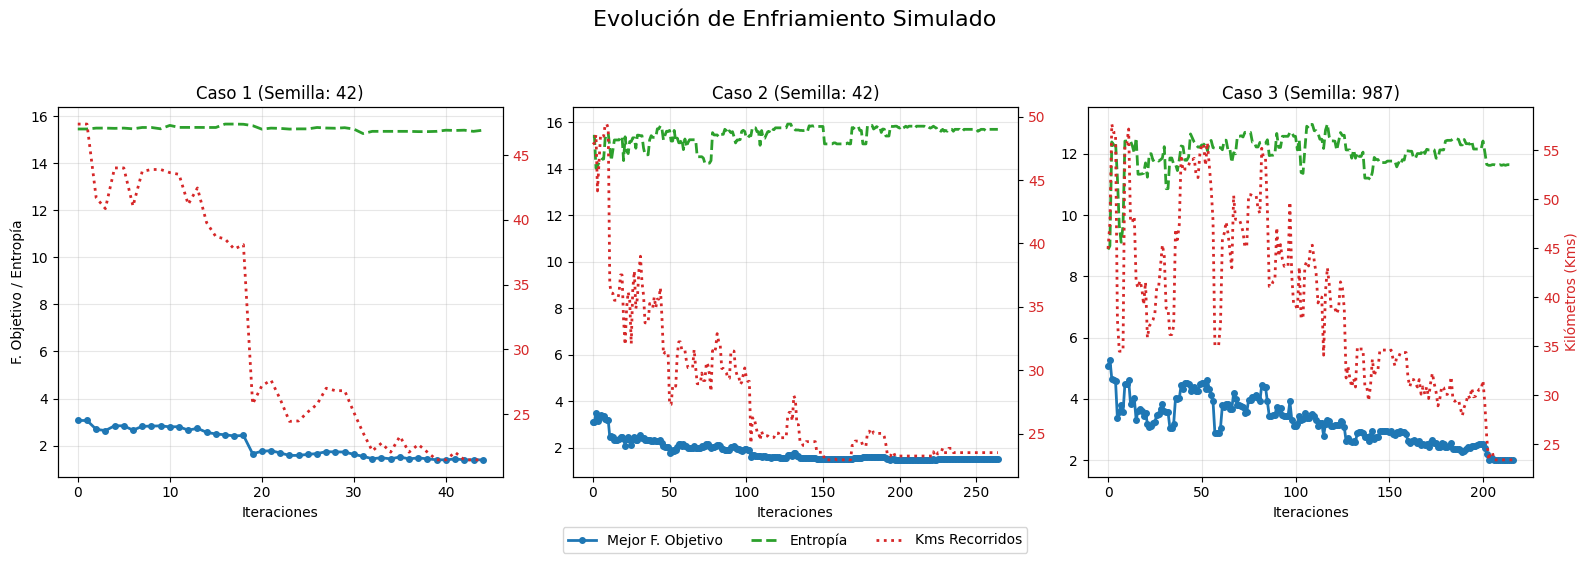

In [6]:
from algorithms import busqueda_enfriamiento_simulado

# Ejecutar Enfriamiento Simulado
res_enfriamiento = ejecutar_experimento(
    nombre_algoritmo='Enfriamiento Simulado',
    funcion_algoritmo=busqueda_enfriamiento_simulado,
    is_deterministic=False,
    max_iteraciones=80, max_vecinos=20,
    res_greedy=res_greedy
)

### **Análisis de Resultados: Enfriamiento Simulado**

A partir de los datos tabulados, el proceso de calibración y el estudio de las curvas de convergencia, se extraen las siguientes conclusiones analíticas:

- **Calibración Termodinámica y Rigidez Espacial**:
La fase de calibración inicial reveló una característica intrínseca del espacio de búsqueda topológico: la fuerte penalización impuesta por la función objetivo hace que el sistema sea extremadamente "rígido". Con parámetros exploratorios bajos ($\mu=0.1, \phi=0.1$), la tasa de rechazo ascendió hasta el $78\%$, limitando la capacidad del algoritmo para saltar a valles peores. Para aproximarse a la directriz teórica del $20\%$ de rechazo, el calibrador interno seleccionó de forma autónoma los valores máximos permitidos por el modelo: **$\mu=0.3$** y **$\phi=0.3$**. Esta inyección térmica ($T_0=0.3859$) logró un $41.0\%$ de rechazo inicial, garantizando la flexibilidad probabilística necesaria para la primera fase de exploración.

- **Superioridad en la Calidad de la Solución (Score)**:
El Enfriamiento Simulado supera de forma drástica a las Búsquedas Locales puras (Primer Mejor y Mejor Vecino) en la totalidad de los escenarios evaluados:
  - En el *Caso 1*, establece un nuevo récord global de **$1.3927$**, logrando una ruta altamente optimizada ($21.46$ Kms) sin sacrificar la entropía del sistema ($15.40$).
  - En el *Caso 2*, la mejora es igualmente notable, rompiendo la barrera del $1.5$ para establecerse en **$1.4676$** ($23.23$ Kms, $15.82$ Entropía).
  - En el *Caso 3* (el escenario de mayor complejidad estructural), se observa el impacto más agresivo de la metaheurística, reduciendo el score a **$2.0116$**. Esto se logra recorriendo casi dos kilómetros menos que la mejor solución local previa, manteniendo una distribución final casi idéntica.

- **El Auto-Ajuste del Parámetro $L(T)$**:
Cumpliendo con la metodología experimental exigida, el algoritmo probó de forma transparente tres longitudes distintas para las cadenas de Markov en cada ciclo de enfriamiento. De manera consistente a través de los tres datasets, la configuración ganadora resultó ser **$L(T) = 15$**. Esto demuestra que, para la presente formulación matemática, es más eficiente enfriar el sistema con mayor frecuencia iterativa que estancar la temperatura durante ciclos largos de $20$ o $25$ evaluaciones.

- **Análisis del Comportamiento Visual**:
La observación de las curvas de convergencia confirma el correcto funcionamiento del modelo termodinámico. A diferencia de las caídas monotónicas de la Búsqueda Local, la gráfica de Enfriamiento Simulado muestra periodos transitorios de empeoramiento controlado (aumentos momentáneos en el Score), especialmente en las primeras iteraciones donde la temperatura de Cauchy es alta. Estos movimientos hacia soluciones subóptimas son los que permitieron al algoritmo evadir las cuencas de atracción locales en las que habían quedado atrapados los algoritmos anteriores.

- **Coste Computacional (Evaluaciones y T. Medio)**:
La superioridad algorítmica reflejada en los scores impone una exigencia computacional predecible. El Enfriamiento requiere un volumen denso y constante de **$4803.0$ evaluaciones medias**, derivado matemáticamente de sus parámetros estáticos ($80$ iteraciones multiplicadas por los vecinos de la cadena de Markov).

---

### **Experimento 6: Búsqueda Tabú**

El algoritmo de **Búsqueda Tabú** es una metaheurística avanzada de optimización que emplea estructuras de memoria adaptativas para guiar la exploración del espacio de búsqueda. A diferencia de otros enfoques, esta técnica previene activamente el ciclado cíclico y permite evadir óptimos locales al prohibir temporalmente movimientos recientes, equilibrando la intensificación local y la diversificación global.

Al igual que en algoritmos previos, se exploran vecindarios espaciales, pero la aceptación de los movimientos está condicionada por reglas de registro histórico. La dinámica de exploración se rige por las siguientes especificaciones impuestas:

1. **Estrategia de Selección y Memoria a Corto Plazo**: en cada iteración se examina un entorno de 20 vecinos para seleccionar el mejor candidato. Para evitar estancamientos, se emplea una *Lista Tabú* (de tamaño inicial $n=4$) que memoriza y prohíbe los movimientos espaciales (índices) recientemente intercambiados. Un vecino considerado tabú será rechazado, salvo que cumpla con el **Criterio de Aspiración**; es decir, que su Función Objetivo supere al mejor récord histórico global, en cuyo caso será aceptado como válido.

2. **Codificación y Memoria a Largo Plazo**: el histórico general de la trayectoria espacial se monitoriza mediante una matriz bidimensional `Frecuencia[N][N]`. Al concluir cada iteración, se registran los arcos del recorrido actual: si la ruta viaja del nodo $i$ al nodo $j$, se incrementa el registro `Frecuencia[i][j] += 1`.

3. **Estrategias de Reinicialización**: el algoritmo programa 4 saltos de reinicialización distribuidos a lo largo de su ejecución (uno cada $N/4$ iteraciones totales). En estos puntos, se altera la estructura del algoritmo vaciando la lista tabú y modificando su capacidad de restricción ($\pm 50\%$ de forma aleatoria uniforme). Posteriormente, el punto de partida de la búsqueda se reinicia según una ruleta probabilística:
    - **$25\%$ de probabilidad** de construir una nueva solución aleatoria.
    - **$25\%$ de probabilidad** de retomar la explotación desde la mejor solución global conocida.
    - **$50\%$ de probabilidad** de emplear la memoria a largo plazo mediante un **Greedy Probabilístico**. Este método favorece la diversificación, priorizando los trayectos menos visitados al construir una ruta basada en la normalización de las inversas de la matriz de frecuencias.

#### **Características**

- **Naturaleza Dirigida por Memoria**: a diferencia de las heurísticas ciegas (Búsquedas Locales puras) o las estocásticas puras (Enfriamiento), el equilibrio entre la exploración de nuevas áreas topológicas y la explotación profunda está directamente orquestado por el aprendizaje de la matriz de frecuencias y el tamaño dinámico de la lista tabú.
- **Condiciones de Parada**: El algoritmo finaliza su ejecución tras completar un número total máximo de iteraciones previamente estimado.
- **Ejecución**: Dado el profundo carácter estocástico de las estrategias de reinicialización y la generación probabilística, el modelo debe ejecutarse 5 veces para cada dataset, asegurando un análisis estadístico fiable utilizando 5 semillas predefinidas distintas.


 EXPERIMENTACIÓN: BÚSQUEDA TABÚ


| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) | Semilla | Mejor FObj |
-----------------------------------------------------------------------------------------------------------
| Caso 1 |      1.3962 |   21.46 |  15.3671 |   3005.0 |      3005 |       0.0492 |     555 | ratio      |
| Caso 2 |      1.4359 |   22.69 |  15.7992 |   3005.0 |      3005 |       0.0479 |    2024 | ratio_cuad |
| Caso 3 |      2.1568 |   25.28 |  11.7194 |   3005.0 |      3005 |       0.0460 |     123 | suma_ponde |
-----------------------------------------------------------------------------------------------------------


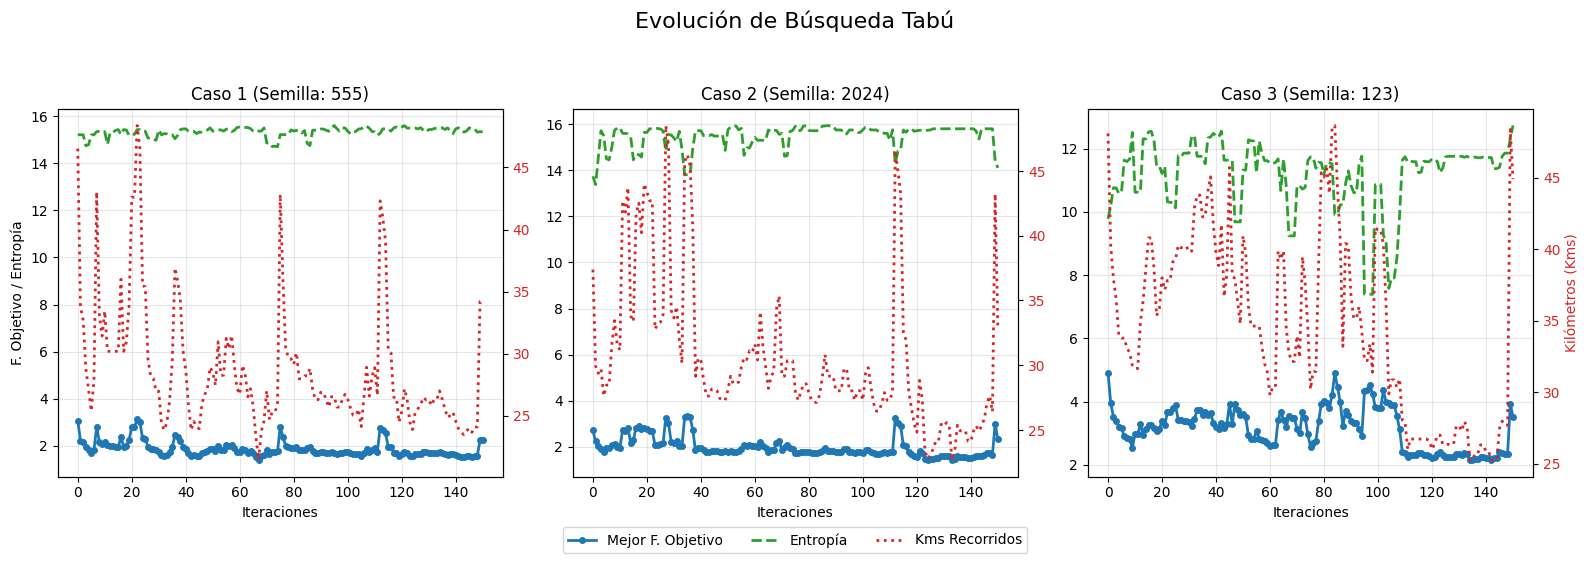

In [7]:
from algorithms import busqueda_tabu

# Ejecutar Búsqueda Tabú
res_tabu = ejecutar_experimento(
    nombre_algoritmo='Búsqueda Tabú',
    funcion_algoritmo=busqueda_tabu,
    is_deterministic=False,
    max_iteraciones=150,
    vecinos_por_iteracion=20
)

### **Análisis de Resultados: Búsqueda Tabú**

A partir de los datos tabulados y el estudio exhaustivo de las curvas de convergencia generadas por la Búsqueda Tabú, se extraen las siguientes conclusiones sobre el comportamiento de esta metaheurística:

- **Calidad de la Solución y Competitividad**: el algoritmo demuestra ser extraordinariamente robusto, logrando equilibrar la red con resultados que compiten directamente con los otros algoritmos, incluso superándolos en cierto escenarios.

- **Comportamiento Visual y Estrategias de Reinicialización**: las graficas ilustran a la perfección la mecánica teórica del algoritmo exigida en las especificaciones. A lo largo de las 150 iteraciones, se observano dos fenómenos muy marcados:
    - **Oscilaciones menores (Memoria a Corto Plazo)**: los pequeños picos continuos en la linea azul demuestran el efecto de la *Lista Tabú*. El algoritmo se ve forzado a aceptar movimientos que empeoran temporalmente el *Score* para no repetir trayectorias recientes, escapando así del fondo del valle local.
    - **Rupturas topológica (Reinicializaciones)**: el algoritmo ejecuta 4 reinicializaciones estratégicas, ocurriendo matemáticamente cada  $\approx 37$ iteraciones (iteraciones $37, 75, 112$). Si se observa los tres gràficos, en estos puntos exactos se producen *picos masivos* donde los kilómetros (linea roja) y la función objetivo se disparan. Esto evidencia visualmente el salto estocástico hacia zonas completamente inexploradas del mapa (ya sea mediante soluciones aleatorias o mediante el Greedy Probabilístico basado en la matriz de frecuencias ), permitiendo al sistema reiniciar su descenso en un nuevo valle topológico.

- **Eficiencia Computacional (`Ev. Media` y `T. Medio`)**: el coste del algoritmo es completamente estático y predecible, fijándose en $3005.0$ evaluaciones por ejecución ($150$ iteraciones $\times$ $20$ vecinos, más las evaluaciones de reinicio). Sin embargo, el análisis del `T. Medio (s)` revela que la Búsqueda Tabú se ejecuta en apenas $\approx 0.041$ segundos.

- **Adaptabilidad de la Función Objetivo**: al igual que en experimentos anteriores, la tabla de resultados subraya la necesidad de disponer de múltiples configuraciones matemáticas. Cada caso encontró su punto mejor guiado por una función objetivo diferente: el *Caso 1* triunfó usando el `ratio` simple, el *Caso 2* rompió el récord guiado por el `ratio_cuad`, y el *Caso 3* obtuvo su mejor rendimiento bajo la métrica `suma_ponde`. La interacción entre las funciones objetivo y la heurística de memoria subraya la complejidad no lineal del problema de enrutamiento y balanceo.

---